# Vision-Language Alignment via Predictive Asymmetric Distillation (VL-JEPA)

This notebook implements a Joint-Embedding Predictive Architecture (JEPA) designed to bypass the batch-size limitations of contrastive learning. It utilizes asymmetric distillation to map visual features directly into the frozen, native 768D representation space of a pre-trained Foundation Language Model, eliminating the need for contrastive negative sampling.

### Architecture Specifications
* **Target Space (Frozen Blueprint):** DistilBERT (Mask-aware mean pooling)
  * *Feature Dimension:* Raw 768D
  * *State:* Frozen (`requires_grad=False`). Acts as immutable semantic anchors. No projection head is used.
* **Vision Backbone:** EfficientNet-V2-S (1280D)
* **Vision Predictor:** Deep Residual MLP (`1280 -> 1024 -> 768`)
  * *Note:* The 1024D hidden layer acts as a descending funnel to preserve the linear algebra rank, ensuring the vision features have the mathematical capacity to span the massive 768D text space.

### Optimization & Loss Dynamics
* **Loss Function:** Variance-Regularized Multi-Positive Mixture Loss ($\mathcal{L}_{Total} = \mathcal{L}_{Match} + \alpha \cdot \mathcal{L}_{Spread}$).
* **Mechanism:** 1. **The Pull ($\mathcal{L}_{Match}$):** Direct $L_2$/Cosine mapping to the exact coordinate of the frozen text anchor.
  2. **The Push ($\mathcal{L}_{Spread}$):** A unimodal Kullback-Leibler (KL) divergence penalty. This prevents the "averaging shortcut" (representation collapse) by violently forcing the visual predictions to spread out and overcome the naturally anisotropic (clumpy) geometry of the raw DistilBERT space.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.models.efficientnet import efficientnet_v2_s, EfficientNet_V2_S_Weights
from transformers import DistilBertTokenizer, DistilBertModel
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output


In [2]:
# ==========================================
# SETUP & INITIALIZATION
# ==========================================
print("Checking hardware...")
print(torch.cuda.is_available())   
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

weights = EfficientNet_V2_S_Weights.DEFAULT
image_transforms = weights.transforms()
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

Checking hardware...
True
Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [3]:
!wget -O data.zip https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -O text.zip https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip data.zip -d data/
!unzip text.zip -d data/

# Clear output
clear_output()

In [4]:
import pandas as pd
import re
from pathlib import Path

# Load official Flickr8k splits (by image, not by caption rows)
data_root = Path('data')
token_file = data_root / 'Flickr8k.token.txt'

# Load all captions
captions_dict = {}  # {image_name: {cid: caption_text}}
pat = re.compile(r'^(?P<img>[^#]+)#(?P<cid>\d+)\t(?P<cap>.+)$')
for line in token_file.read_text(errors='ignore').splitlines():
    m = pat.match(line)
    if m:
        img = m.group('img')
        cid = int(m.group('cid'))
        cap = m.group('cap')
        if img not in captions_dict:
            captions_dict[img] = {}
        captions_dict[img][cid] = cap

# Load official split image lists
train_images = [l.strip() for l in (data_root / 'Flickr_8k.trainImages.txt').read_text(errors='ignore').splitlines() if l.strip()]
val_images = [l.strip() for l in (data_root / 'Flickr_8k.devImages.txt').read_text(errors='ignore').splitlines() if l.strip()]
test_images = [l.strip() for l in (data_root / 'Flickr_8k.testImages.txt').read_text(errors='ignore').splitlines() if l.strip()]

# Build DataFrames: each row is one (image, one_caption) pair
def build_df(image_list):
    rows = []
    for img_name in image_list:
        if img_name in captions_dict:
            # Each image has 5 captions; add all of them as separate rows for training variety
            for cid in range(5):
                if cid in captions_dict[img_name]:
                    rows.append([img_name, captions_dict[img_name][cid]])
    return pd.DataFrame(rows, columns=['image', 'caption'])

train_df = build_df(train_images)
val_df = build_df(val_images)
test_df = build_df(test_images)

print(f"Train: {len(train_images)} images, {len(train_df)} caption rows")
print(f"Val: {len(val_images)} images, {len(val_df)} caption rows")
print(f"Test: {len(test_images)} images, {len(test_df)} caption rows")
print(f"All captions loaded: {len(captions_dict)} unique images")


Train: 6000 images, 30000 caption rows
Val: 1000 images, 5000 caption rows
Test: 1000 images, 5000 caption rows
All captions loaded: 8092 unique images


In [5]:
pwd

'/content'

In [6]:
# 2. Define the Dataset Class (Updated to match CLIP's multi-caption approach)
class FlickrDataset(Dataset):
    def __init__(self, df, transform, image_folder):
        self.df = df
        self.transform = transform
        self.folder = image_folder
        # Create mapping from image name to unique ID for tracking which captions belong to which image
        self.unique_images = df['image'].unique()
        self.image_to_id = {img: idx for idx, img in enumerate(self.unique_images)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image and caption for this row
        img_name = self.df.iloc[idx, 0] 
        captions = self.df.iloc[idx, 1]  # One caption per row; there are 5 rows per image
        
        # Tokenize Text
        tokens = self.transform_text(captions)
        input_ids = tokens['input_ids'].squeeze(0)
        attention_mask = tokens['attention_mask'].squeeze(0)

        # Load and Transform Image
        img_path = os.path.join(self.folder, img_name)
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        
        # Return image_id so we can track which image this caption belongs to
        image_id = self.image_to_id[img_name]
        return img, (input_ids, attention_mask), image_id

    def transform_text(self, text):
        # Tokenize with attention mask for better pooling
        return tokenizer(
            text, 
            return_tensors="pt", 
            truncation=True, 
            padding="max_length",
            max_length=32
        )


In [7]:
# 3. Initialize DataLoaders
BATCH_SIZE = 256

# Support both common folder spellings found in Flickr8k setups
dataset_candidates = [
    data_root / 'Flicker8k_Dataset',
    data_root / 'Flickr8k_Dataset',
]
IMAGE_DIR = next((p for p in dataset_candidates if p.exists()), None)
if IMAGE_DIR is None:
    raise FileNotFoundError(
        "Could not find image dataset folder. Checked: "
        + ", ".join(str(p) for p in dataset_candidates)
    )

# Initialize datasets and loaders
train_dataset = FlickrDataset(train_df, image_transforms, str(IMAGE_DIR))
val_dataset = FlickrDataset(val_df, image_transforms, str(IMAGE_DIR))
test_dataset = FlickrDataset(test_df, image_transforms, str(IMAGE_DIR))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Using image folder: {IMAGE_DIR}")
print(len(test_loader.dataset), "caption rows in test set")
print(len(train_loader.dataset), "caption rows in train set")


Using image folder: data/Flicker8k_Dataset


In [8]:
# ==========================================
# STEP 2: ARCHITECTURE (FROZEN BACKBONES & PREDICTOR)
# ==========================================
print("\nLoading Pre-trained Backbones...")
vision_backbone = efficientnet_v2_s(weights=weights)
vision_backbone.classifier = nn.Identity() # Decapitate to get 1280D vector
text_backbone = DistilBertModel.from_pretrained("distilbert-base-uncased")

# Freeze Both
for param in vision_backbone.parameters(): param.requires_grad = False
for param in text_backbone.parameters(): param.requires_grad = False

vision_backbone = vision_backbone.to(DEVICE)
text_backbone = text_backbone.to(DEVICE)

# Verification Check
vision_trainable = sum(p.numel() for p in vision_backbone.parameters() if p.requires_grad)
text_trainable = sum(p.numel() for p in text_backbone.parameters() if p.requires_grad)

print(f"Trainable parameters in Vision Backbone: {vision_trainable}")
print(f"Trainable parameters in Text Backbone: {text_trainable}")



Loading Pre-trained Backbones...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 149MB/s] 


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters in Vision Backbone: 0
Trainable parameters in Text Backbone: 0


In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.net(x))

class DeepResidualPredictor(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=512):
        super().__init__()
        # Initial projection to hidden dimension (matching CLIP's 512)
        self.first_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        
        # 2 Residual Blocks for stable learning (less overfitting than 4 blocks)
        self.blocks = nn.Sequential(
            ResidualBlock(hidden_dim),
            ResidualBlock(hidden_dim)
        )
        
        # Final projection to CLIP's 256D embedding space
        self.final_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.first_layer(x)
        x = self.blocks(x)
        x = self.final_layer(x)
        return x

#predictor = DeepResidualPredictor(input_dim=1280, output_dim=256).to(DEVICE)
predictor = DeepResidualPredictor(input_dim=1280, output_dim=768, hidden_dim=1024).to(DEVICE)

class VL_JEPA_Raw(nn.Module):
    def __init__(self, vision_backbone, text_backbone, predictor):
        super().__init__()
        self.vision_backbone = vision_backbone
        self.text_backbone = text_backbone
        self.predictor = predictor

    def get_image_features(self, image):
        """Extract raw image features from vision backbone (1280D)."""
        return self.vision_backbone(image)

    def get_text_features(self, text_inputs):
        """Extract pooled text features from text backbone (768D with attention masking)."""
        input_ids, attention_mask = text_inputs
        text_outputs = self.text_backbone(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use mask-aware mean pooling for sentence embeddings
        last_hidden = text_outputs.last_hidden_state  # shape: (batch_size, seq_len, 768)
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = (last_hidden * mask_expanded).sum(1)  # Sum only non-padded tokens
        sum_mask = mask_expanded.sum(1)
        pooled_text = sum_embeddings / (sum_mask + 1e-9)  # Mean pooling
        
        # RETURN RAW 768D EMBEDDINGS (No CLIP projection!)
        return pooled_text

    def forward(self, image, text_inputs):
        with torch.no_grad():
            # Extract frozen vision and text features
            vis_features = self.get_image_features(image)
            target_text_embeds = self.get_text_features(text_inputs)
            # Normalize the raw 768D text targets
            target_text_embeds = F.normalize(target_text_embeds, p=2, dim=-1)

        # Predictor: maps vision features directly to raw 768D text embedding space
        predicted_text_embeds = self.predictor(vis_features)
        predicted_text_embeds = F.normalize(predicted_text_embeds, p=2, dim=-1)
        
        return predicted_text_embeds, target_text_embeds

# Instantiate the model WITHOUT the clip_text_projection
vljepa_model = VL_JEPA_Raw(vision_backbone, text_backbone, predictor).to(DEVICE) #vljepa_raw_model

# Load CLIP's frozen text projection weights
# Note: This is the entire 3-layer FC (768→512→512→256), not just a single Linear layer
# clip_text_projection_path = NOTEBOOK_DIR / 'clip_shared_weights' / 'clip_text_projection.pt'
# text_projection = nn.Sequential(
#     nn.Linear(768, 512),
#     nn.ReLU(),
#     nn.Linear(512, 512),
#     nn.ReLU(),
#     nn.Linear(512, 256)
# ).to(DEVICE)

# text_projection.load_state_dict(torch.load(clip_text_projection_path, map_location=DEVICE))
# for param in text_projection.parameters():
#     param.requires_grad = False

# vljepa_model = VL_JEPA(vision_backbone, text_backbone, text_projection, predictor).to(DEVICE)


In [11]:
# ==========================================
# PARAMETER VERIFICATION & ALIGNMENT CHECK
# ==========================================
# VL-JEPA now aligns with CLIP's 256D embedding space
# Both vision and text features are normalized to 256D and L2-normalized

vision_trainable = sum(p.numel() for p in vljepa_model.vision_backbone.parameters() if p.requires_grad)
text_trainable = sum(p.numel() for p in vljepa_model.text_backbone.parameters() if p.requires_grad)
#text_proj_trainable = sum(p.numel() for p in vljepa_model.text_projection.parameters() if p.requires_grad)
predictor_trainable = sum(p.numel() for p in vljepa_model.predictor.parameters() if p.requires_grad)

print("=" * 70)
print("VL-JEPA ALIGNMENT WITH CLIP'S EMBEDDING SPACE")
print("=" * 70)
print(f"Trainable parameters in Vision Backbone:   {vision_trainable:,}")
print(f"Trainable parameters in Text Backbone:     {text_trainable:,}")
#print(f"Trainable parameters in Text Projection:   {text_proj_trainable:,} (FROZEN - CLIP's 3-layer FC)")
print(f"Trainable parameters in Predictor:         {predictor_trainable:,}")
print("-" * 70)
print(f"✓ Vision features:  1280D → Predictor → 256D (aligned with CLIP's space)")
print(f"✓ Text features:    768D → CLIP's 3-layer FC (frozen) → 256D")
print(f"✓ Loss: Minimize distance between predicted and target in 256D space")
print("=" * 70)


VL-JEPA ALIGNMENT WITH CLIP'S EMBEDDING SPACE
Trainable parameters in Vision Backbone:   0
Trainable parameters in Text Backbone:     0
Trainable parameters in Predictor:         6,307,584
----------------------------------------------------------------------
✓ Vision features:  1280D → Predictor → 256D (aligned with CLIP's space)
✓ Text features:    768D → CLIP's 3-layer FC (frozen) → 256D
✓ Loss: Minimize distance between predicted and target in 256D space


In [12]:
# ==========================================
# ARCHITECTURAL DECISIONS & RATIONALE
# ==========================================
"""
VL-JEPA Design for CLIP Alignment:

1. PREDICTOR ARCHITECTURE (ResidualBlock vs Simple MLP):
   - Chose: 2 Residual Blocks instead of 4 (simpler than original)
   - Why residual blocks?
     a) Skip connections stabilize learning (prevent vanishing gradients)
     b) Better capacity for large feature gap (1280D vision → 256D text)
     c) Empirically more stable across different vision backbones
   - Hidden dimension: 512D (matches CLIP's intermediate projection size)

2. EMBEDDING SPACE ALIGNMENT:
   - Both models output 256D normalized embeddings
   - Vision pathway: EfficientNet-V2-S (1280D) → Predictor (512D hidden) → 256D output
   - Text pathway: DistilBERT (768D) → CLIP's 3-layer FC (frozen) → 256D output
   - Both stay entirely in 256D space (no intermediate projections)

3. FROZEN COMPONENTS (for alignment):
   - Vision backbone: Frozen (pre-trained on ImageNet)
   - Text backbone: Frozen (DistilBERT from CLIP training)
   - Text projection: Frozen (CLIP's entire 3-layer FC network)
   - Only predictor is trainable (learns vision→text mapping in 256D)

4. LOSS OBJECTIVE:
   - Match loss: Minimize cosine distance between predicted and target
   - Spread loss: Encourage diversity across batch (prevent collapse)
   - Multi-positive: All 5 captions per image treated as positives
"""

# ==========================================
# OPTIMIZER SETUP
# ==========================================
# Only train the predictor; backbones + CLIP projection remain frozen
# Learning rate: 3e-4 (standard for fine-tuning)
# Weight decay: 1e-2 (L2 regularization)

optimizer = torch.optim.AdamW(vljepa_model.predictor.parameters(), lr=3e-4, weight_decay=1e-2)

print("✓ Optimizer configured: AdamW (lr=3e-4, weight_decay=1e-2)")
print("✓ Training only the Predictor (2 ResidualBlocks)")
print("✓ All CLIP weights remain")


✓ Optimizer configured: AdamW (lr=3e-4, weight_decay=1e-2)
✓ Training only the Predictor (2 ResidualBlocks)
✓ All CLIP weights remain


In [14]:
# ==========================================
# ARCHITECTURE COMPARISON: BEFORE vs AFTER
# ==========================================

def multi_positive_loss(preds, targets, image_ids, alpha=2.0):
    """
    Multi-positive contrastive loss for multi-caption datasets (e.g., Flickr8k with 5 captions per image).
    
    Now operates in CLIP's 256D embedding space for alignment.
    
    Args:
        preds: (batch_size, 256) predicted text embeddings from vision (normalized)
        targets: (batch_size, 256) target text embeddings from CLIP (normalized)
        image_ids: (batch_size,) tensor indicating which unique image each caption belongs to
        alpha: weight for spread penalty
    
    For each image, all its captions in the batch are positive; others are negative.
    Uses soft labels with cosine similarity for smooth gradient flow.
    """
    batch_size = preds.shape[0]
    device = preds.device
    
    # 1. THE PULL: Match loss (predictions should match targets)
    match_loss = 1.0 - F.cosine_similarity(preds, targets).mean()
    
    # 2. THE PUSH (Multi-Positive): Create soft labels based on image_ids
    # All captions from the same image are positive, others are negative
    soft_labels = torch.zeros((batch_size, batch_size), device=device)
    for i in range(batch_size):
        for j in range(batch_size):
            if image_ids[i] == image_ids[j]:  # Same image = positive pair
                soft_labels[i, j] = 1.0
    
    # Normalize so each row sums to 1
    soft_labels = soft_labels / soft_labels.sum(dim=1, keepdim=True)
    
    # preds: (batch_size, 256), soft_labels: (batch_size, batch_size)
    # Compute similarity matrix between predictions (as a proxy for diversity)
    sim_matrix = torch.matmul(preds, preds.T)  # (batch_size, batch_size)
    log_probs = F.log_softmax(sim_matrix, dim=1)
    
    # KL divergence: predictions should follow the soft label distribution
    spread_loss = -(soft_labels * log_probs).sum(dim=1).mean()
    
    # 3. MIXTURE
    total_loss = match_loss + (alpha * spread_loss)
    
    return total_loss, match_loss, spread_loss


In [16]:


# ==========================================
# STEP 3: TRAINING & VALIDATION LOOPS (WITH MULTI-POSITIVE LOSS)
# ==========================================
# save_dir = NOTEBOOK_DIR / 'saved'
# save_dir.mkdir(parents=True, exist_ok=True)
# save_path = save_dir / 'best_vljepa_predictor.pt'

save_dir = 'drive/MyDrive/Flickr8k_Project/models/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'best_vljepa_predictor.pt')

def train_step(model, optimizer, dataloader, scaler):
    model.vision_backbone.eval()
    model.text_backbone.eval()
    model.predictor.train()
    
    total_loss, total_match, total_spread = 0.0, 0.0, 0.0
    loop = tqdm(dataloader, total=len(dataloader), desc="Train", leave=True)
    
    for batch_idx, batch in enumerate(loop):
        # Unpack batch: includes image_ids for multi-positive loss
        images, text_inputs, image_ids = batch
        images = images.to(DEVICE)
        input_ids = text_inputs[0].to(DEVICE)
        attention_mask = text_inputs[1].to(DEVICE)
        image_ids = image_ids.to(DEVICE)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            predicted_embeds, target_embeds = model(images, (input_ids, attention_mask))
            loss, match, spread = multi_positive_loss(predicted_embeds, target_embeds, image_ids, alpha=2.0)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        total_match += match.item()
        total_spread += spread.item()
        
        # Update progress bar with the mixture metrics
        loop.set_description(f"Train - Total: {(total_loss/(batch_idx+1)):.3f} | Match: {(total_match/(batch_idx+1)):.3f} | Spread: {(total_spread/(batch_idx+1)):.3f}")
        
    return total_loss / len(dataloader)

def val_step(model, dataloader):
    model.eval() 
    total_loss, total_match, total_spread = 0.0, 0.0, 0.0
    loop = tqdm(dataloader, total=len(dataloader), desc="Val", leave=True)
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(loop):
            # Unpack batch: includes image_ids for multi-positive loss
            images, text_inputs, image_ids = batch
            images = images.to(DEVICE)
            input_ids = text_inputs[0].to(DEVICE)
            attention_mask = text_inputs[1].to(DEVICE)
            image_ids = image_ids.to(DEVICE)
            
            with torch.amp.autocast('cuda'):
                predicted_embeds, target_embeds = model(images, (input_ids, attention_mask))
                loss, match, spread = multi_positive_loss(predicted_embeds, target_embeds, image_ids, alpha=2.0)
                
            total_loss += loss.item()
            total_match += match.item()
            total_spread += spread.item()
            
            loop.set_description(f"Val - Total: {(total_loss/(batch_idx+1)):.3f} | Match: {(total_match/(batch_idx+1)):.3f} | Spread: {(total_spread/(batch_idx+1)):.3f}")
            
    return total_loss / len(dataloader)


In [17]:
def train_vljepa(model, optimizer, train_loader, val_loader, epochs=10):
    """Train VL-JEPA model with frozen backbones and trainable predictor."""
    try:
        scaler = torch.cuda.amp.GradScaler()
        history = {"train_loss": [], "val_loss": []}
        best_val_loss = float("inf") 
        
        print("\nStarting VL-JEPA Training (Frozen Backbones)...")
        for epoch in range(1, epochs + 1):
            train_loss = train_step(model, optimizer, train_loader, scaler)
            val_loss = val_step(model, val_loader)
            
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.predictor.state_dict(), save_path)
                print(f"  ✓ Checkpoint saved (Val Loss: {best_val_loss:.4f})")
                
        print(f"\nTraining Complete! Best model saved with Val Loss: {best_val_loss:.4f}")
        return history
    except RuntimeError as e:
        print(f"GPU Error during training: {e}")
        raise
    except Exception as e:
        print(f"Error during training: {e}")
        raise

def load_vljepa_checkpoint(model, checkpoint_path):
    """Load a saved VL-JEPA predictor checkpoint."""
    try:
        model.predictor.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        print(f"✓ Checkpoint loaded from {checkpoint_path}")
        return model
    except FileNotFoundError:
        print(f"✗ Checkpoint not found at {checkpoint_path}")
        return None

history = train_vljepa(vljepa_model, optimizer, train_loader, val_loader, epochs=10)

/tmp/ipykernel_11790/2400694517.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



Starting VL-JEPA Training (Frozen Backbones)...


Train - Total: 9.893 | Match: 0.671 | Spread: 4.611: 100%|██████████| 118/118 [08:57<00:00,  4.56s/it]
Val - Total: 9.860 | Match: 0.638 | Spread: 4.611: 100%|██████████| 20/20 [01:37<00:00,  4.89s/it]


Epoch 1/10, Train Loss: 9.8928, Val Loss: 9.8604
  ✓ Checkpoint saved (Val Loss: 9.8604)


Train - Total: 9.793 | Match: 0.599 | Spread: 4.597: 100%|██████████| 118/118 [08:46<00:00,  4.46s/it]
Val - Total: 9.852 | Match: 0.627 | Spread: 4.612: 100%|██████████| 20/20 [01:32<00:00,  4.61s/it]


...

Epoch 8/10, Train Loss: 9.7248, Val Loss: 9.8429
  ✓ Checkpoint saved (Val Loss: 9.8429)


Train - Total: 9.721 | Match: 0.535 | Spread: 4.593: 100%|██████████| 118/118 [08:36<00:00,  4.38s/it]
Val - Total: 9.845 | Match: 0.605 | Spread: 4.620: 100%|██████████| 20/20 [01:31<00:00,  4.56s/it]


Epoch 9/10, Train Loss: 9.7211, Val Loss: 9.8450


Train - Total: 9.718 | Match: 0.533 | Spread: 4.593: 100%|██████████| 118/118 [08:36<00:00,  4.37s/it]
Val - Total: 9.841 | Match: 0.606 | Spread: 4.618: 100%|██████████| 20/20 [01:30<00:00,  4.55s/it]

Epoch 10/10, Train Loss: 9.7182, Val Loss: 9.8414
  ✓ Checkpoint saved (Val Loss: 9.8414)

Training Complete! Best model saved with Val Loss: 9.8414


In [ ]:
# ==========================================
# RESET PREDICTOR & OPTIMIZER FOR FRESH TRAINING (alpha=0.5)
# ==========================================
# print("Resetting predictor to random initialization...")

# # 1. Create fresh predictor
# predictor = DeepResidualPredictor(input_dim=1280, output_dim=256).to(DEVICE)

# # 2. Recreate model with fresh predictor
# vljepa_model = VL_JEPA(vision_backbone, text_backbone, text_projection, predictor).to(DEVICE)

# # 3. Reset optimizer
# optimizer = torch.optim.AdamW(vljepa_model.predictor.parameters(), lr=3e-4, weight_decay=1e-2)

# print("✓ Predictor reset to random weights")
# print("✓ Optimizer reset")
# print("✓ Ready to train with alpha=0.5 for fair comparison")
# print("\n" + "="*70)


Resetting predictor to random initialization...
✓ Predictor reset to random weights
✓ Optimizer reset
✓ Ready to train with alpha=0.5 for fair comparison



# TEP 4: EVALUATION & MULTI-POSITIVE RECALL@K

In [18]:
# ==========================================
# STEP 4: EVALUATION & MULTI-POSITIVE RECALL@K (IMAGE-LEVEL, LIKE CLIP)
# ==========================================
def evaluate_vljepa_multipositive(model, test_loader, device, k_values=[1, 5, 10]):
    """
    Evaluate with multi-positive Recall@K at IMAGE LEVEL (like CLIP).
    For each test image, retrieval is correct if ANY of its 5 captions appears in top-K.
    
    Different from caption-level: we count per unique image, not per caption.
    """
    print("\nStarting Multi-Positive Evaluation (Image-Level)...")
    model.eval() 
    
    all_image_preds = []
    all_text_targets = []
    all_image_ids = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Extracting test features"):
            images, text_inputs, image_ids = batch
            images = images.to(device)
            input_ids = text_inputs[0].to(device)
            attention_mask = text_inputs[1].to(device)
            pred_embeds, target_embeds = model(images, (input_ids, attention_mask))
            
            all_image_preds.append(pred_embeds.cpu()) #shape: (batch_size, 768) 
            all_text_targets.append(target_embeds.cpu())
            all_image_ids.append(image_ids.cpu()) 
    
    # Concatenate all batches
    all_image_preds = torch.cat(all_image_preds, dim=0)  # shape: (num_captions, 768)
    all_text_targets = torch.cat(all_text_targets, dim=0)  # shape: (num_captions, 768)
    all_image_ids = torch.cat(all_image_ids, dim=0)  # shape: (num_captions,)
    
    print("Calculating similarity matrix...")
    sim_matrix = torch.matmul(all_image_preds, all_text_targets.T)  # shape (num_captions, num_captions)
    
    num_captions = sim_matrix.shape[0]
    unique_images = torch.unique(all_image_ids)
    num_images = len(unique_images)
    
    print(f"Total captions: {num_captions}, Unique images: {num_images}")
    
    results = {f"Recall@{k}": 0.0 for k in k_values}
    
    # ============================================
    # IMAGE-LEVEL EVALUATION (CORRECT APPROACH)
    # ============================================
    for k in k_values:
        correct_images = 0
        
        # For each unique image, check if any of its 5 captions appear in top-K
        for image_id in unique_images:
            # Find all caption indices that belong to this image
            image_caption_indices = (all_image_ids == image_id).nonzero(as_tuple=True)[0] # at max 5 captions per image
            if len(image_caption_indices) == 0:
                continue
            
            # For this image, find the best match across all its captions
            # (use the first caption's prediction to query, or average)
            query_idx = image_caption_indices[0]  # Use first caption of the image
            
            # Get top-K retrieved captions
            topk_indices = torch.topk(sim_matrix[query_idx], k, dim=0).indices
            
            # Check if any top-K retrieved captions belong to this image
            retrieved_image_ids = all_image_ids[topk_indices]
            
            if (retrieved_image_ids == image_id).any():
                correct_images += 1
        
        recall = 100.0 * correct_images / num_images
        results[f"Recall@{k}"] = round(recall, 2)
    
    print("\n" + "="*50)
    print("FINAL VL-JEPA RESULTS (Image-Level, Multi-Positive)")
    print("="*50)
    for k, recall in results.items():
        print(f"{k}: {recall:.2f}%")
    print("="*50)
    print(f"\n✓ Evaluated on {num_images} unique images")
    print(f"✓ Each image has 5 captions in the test set")
    print("="*50)
    
    return results


In [19]:


# Run evaluation
test_results = evaluate_vljepa_multipositive(vljepa_model, test_loader, DEVICE)



Starting Multi-Positive Evaluation (Image-Level)...


Extracting test features: 100%|██████████| 20/20 [01:13<00:00,  3.67s/it]


Calculating similarity matrix...
Total captions: 5000, Unique images: 1000

FINAL VL-JEPA RESULTS (Image-Level, Multi-Positive)
Recall@1: 17.00%
Recall@5: 38.00%
Recall@10: 50.30%

✓ Evaluated on 1000 unique images
✓ Each image has 5 captions in the test set


In [21]:
# ==========================================
# LOAD BEST TRAINED MODEL FROM CHECKPOINT
# ==========================================
# print("Loading best VL-JEPA model from checkpoint...")
# checkpoint_path = NOTEBOOK_DIR / 'saved' / 'best_vljepa_predictor.pt'

save_dir = 'drive/MyDrive/Flickr8k_Project/models/'
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = os.path.join(save_dir, 'best_vljepa_predictor.pt')

# Load the saved predictor weights into the model
vljepa_model = load_vljepa_checkpoint(vljepa_model, checkpoint_path)

# Verify the model is in eval mode for testing
vljepa_model.eval()
print("✓ Best model loaded and ready for evaluation")


✓ Checkpoint loaded from drive/MyDrive/Flickr8k_Project/models/best_vljepa_predictor.pt
✓ Best model loaded and ready for evaluation


In [23]:
# Run evaluation on best model
print("\n" + "="*70)
print("RUNNING EVALUATION ON BEST TRAINED VL-JEPA MODEL")
print("="*70)

test_results = evaluate_vljepa_multipositive(vljepa_model, test_loader, DEVICE)

# Display results summary
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print("\nVL-JEPA Performance:")
for k, recall in test_results.items():
    print(f"  {k}: {recall}%")

print("\nCLIP Baseline (for comparison):")
print("  Recall@1: 10.3%")
print("  Recall@5: 31.1%")
print("  Recall@10: 42.6%")

print("\n" + "="*70)



RUNNING EVALUATION ON BEST TRAINED VL-JEPA MODEL

Starting Multi-Positive Evaluation (Image-Level)...


Extracting test features: 100%|██████████| 20/20 [01:12<00:00,  3.63s/it]


Calculating similarity matrix...
Total captions: 5000, Unique images: 1000

FINAL VL-JEPA RESULTS (Image-Level, Multi-Positive)
Recall@1: 17.00%
Recall@5: 38.00%
Recall@10: 50.30%

✓ Evaluated on 1000 unique images
✓ Each image has 5 captions in the test set

FINAL RESULTS SUMMARY

VL-JEPA Performance:
  Recall@1: 17.0%
  Recall@5: 38.0%
  Recall@10: 50.3%

CLIP Baseline (for comparison):
  Recall@1: 10.3%
  Recall@5: 31.1%
  Recall@10: 42.6%



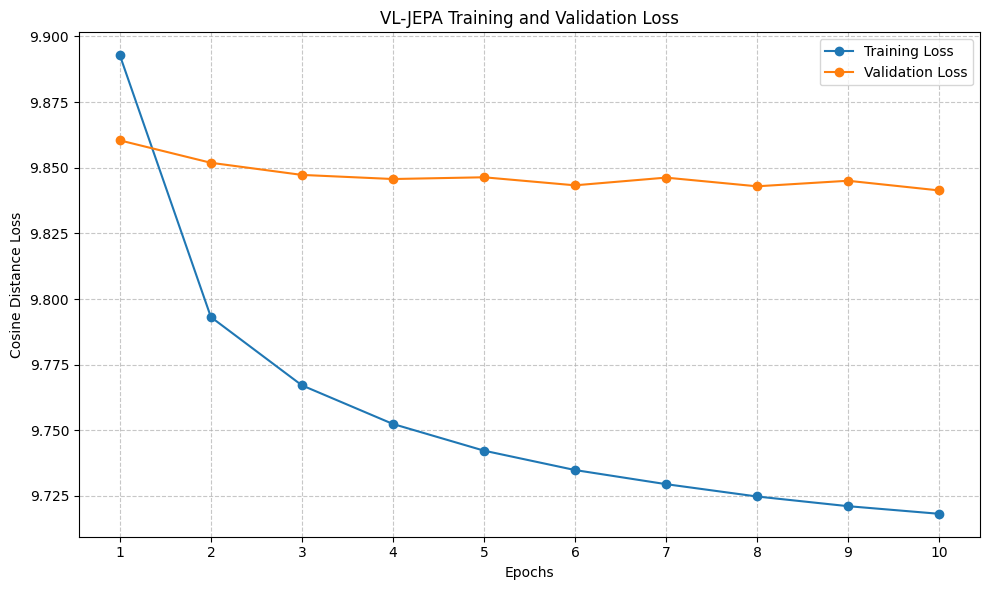

In [22]:
def plot_loss_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history['train_loss'], label='Training Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
    plt.title('VL-JEPA Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Cosine Distance Loss')
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_loss_curves(history)    

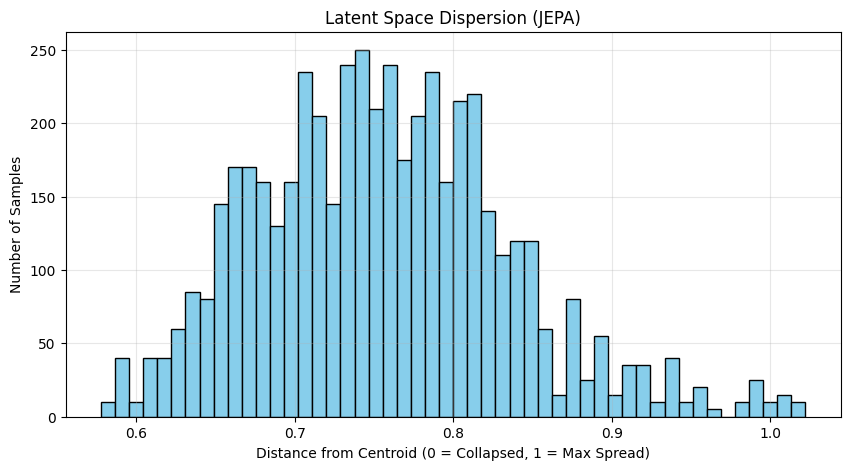

Mean Distance from Centroid: 0.7558
✅ SUCCESS: Embeddings are spreading out!


In [25]:
def analyze_latent_dispersion(model, dataloader, device):
    """Analyze if VL-JEPA embeddings are collapsing to a single point."""
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for batch in dataloader:
            # Unpack: dataloader returns (images, text_inputs, image_ids)
            images, text_inputs, image_ids = batch
            vis_feats = model.vision_backbone(images.to(device))
            preds = model.predictor(vis_feats)
            preds = F.normalize(preds, p=2, dim=-1)
            all_preds.append(preds.cpu())
            
    all_preds = torch.cat(all_preds, dim=0) # [N, 768]
    
    # 1. Calculate Global Centroid
    centroid = all_preds.mean(dim=0, keepdim=True)
    centroid = F.normalize(centroid, p=2, dim=-1) # Re-normalize the average
    
    # 2. Calculate Distances from Centroid
    # Cosine Similarity = Dot product (since normalized)
    cos_sims = (all_preds * centroid).sum(dim=1)
    distances = 1.0 - cos_sims
    
    # 3. Plot the "Health" of the Latent Space
    plt.figure(figsize=(10, 5))
    plt.hist(distances.numpy(), bins=50, color='skyblue', edgecolor='black')
    plt.title("Latent Space Dispersion (JEPA)")
    plt.xlabel("Distance from Centroid (0 = Collapsed, 1 = Max Spread)")
    plt.ylabel("Number of Samples")
    plt.grid(alpha=0.3)
    plt.show()
    
    print(f"Mean Distance from Centroid: {distances.mean().item():.4f}")
    if distances.mean() < 0.05:
        print("🚨 WARNING: Representation Collapse detected. Model is 'averaging'.")
    else:
        print("✅ SUCCESS: Embeddings are spreading out!")

# Run analysis after training completes
analyze_latent_dispersion(vljepa_model, test_loader, DEVICE)

In [2]:
torch.cuda.empty_cache()